Definir la frecuencia de muestreo para la siguiente señal y obtener las muestras de 10
segundos de la señal usando Colab

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window
import scipy.signal as signal

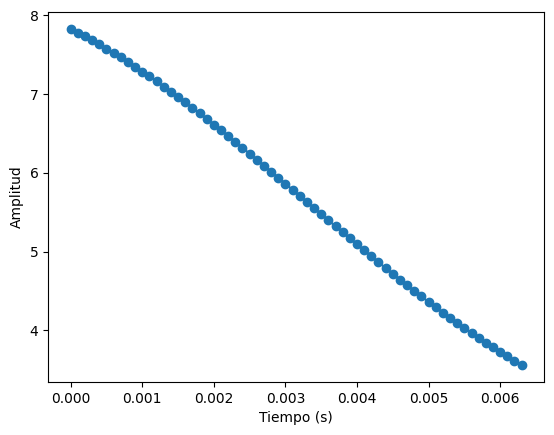

In [26]:
#señal
fs = 10000
Fo = 2*80
Tp = 1/Fo
T = 1/fs
t = np.arange(0, Tp+T, T)

x1= 4 * np.cos(80*np.pi*t + (np.pi /4))
x2 = 2 * np.sin(40*np.pi*t)
x3 = 5

x = x1+x2+x3

plt.plot(t, x, marker='o')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

Periodograma de welch

In [27]:
def welch_periodograma(x, M, S, ventana='hann'):
    segmentos = particionar_senal(x, M, S)

    w = get_window(ventana, M)

    W = np.sum(w ** 2)

    K = segmentos.shape[0]
    periodogramas = []
    for k in range(K):
        segmento_enventanado = segmentos[k] * w
        Xk = np.fft.fft(segmento_enventanado, n=M)
        Pk = (1 / W) * np.abs(Xk) ** 2
        periodogramas.append(Pk)

    periodogramas = np.array(periodogramas)

    Pxx = np.mean(periodogramas, axis=0)

    f = np.fft.fftfreq(M, d=1)

    return f[:M // 2], Pxx[:M // 2]

In [28]:
ventana = 'hamming'
M = 40
S = 30

f, Pxx = welch_periodograma(x, M, S, ventana)
particionar_senal(x,M,S)

array([[7.82842712, 7.78158731, 7.7330025 , 7.68271527, 7.63076928,
        7.57720925, 7.52208089, 7.4654309 , 7.40730691, 7.34775751,
        7.28683213, 7.22458108, 7.16105549, 7.09630725, 7.03038903,
        6.96335419, 6.89525678, 6.8261515 , 6.75609364, 6.68513907,
        6.6133442 , 6.54076592, 6.46746158, 6.39348896, 6.31890622,
        6.24377185, 6.16814466, 6.09208371, 6.01564829, 5.9388979 ,
        5.86189214, 5.78469077, 5.70735357, 5.6299404 , 5.55251106,
        5.47512533, 5.39784289, 5.3207233 , 5.24382594, 5.16720999]])

In [29]:
def particionar_senal(x, M, S):
    x = np.asarray(x).flatten()
    N = len(x)

    K = (N - M) // S + 1
    segmentos = [x[k * S:k * S + M] for k in range(K)]
    return np.array(segmentos)

Filtros

In [34]:
a = 5

fcs = a/50
pasa_altas = signal.firwin(51, fcs, pass_zero=False, window='hamming')



In [35]:
b = 50

fcs = b/50

pasa_bajas = signal.firwin(51, fcs, pass_zero=True, window='hamming')

ValueError: Invalid cutoff frequency: frequencies must be greater than 0 and less than fs/2.